In-Class Activity - Week 3

In [ ]:
%pip install adjustText

In [ ]:
# Create new folder - Week3
# Upload jd_small.csv into the newly created Week3 folder

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from nltk.stem.snowball import SnowballStemmer
snow_stemmer = SnowballStemmer(language='english')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
import nltk
from textblob import TextBlob
from nltk.tokenize import word_tokenize
nltk.download('punkt')
from adjustText import adjust_text
from scipy import stats

# Change path
os.chdir('/content/Week3/')
# check path
print(os.getcwd())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


/content/Week3


In [ ]:
def stemming_tokenizer(str_input):

    # This function will be used to override basic preprocessing steps in TfidfVrctorizer

    words = re.sub(r"[^A-Za-z]", " ", str_input).lower().split()
    words = [snow_stemmer.stem(word) for word in words]

    return words

def TAB_dfm(text, ngrams_range = (1,2),
                stop_words = 'english', min_prop = .01,
                max_features=None):

  # TfidfVectorizer and CountVectorizer removes punctuation automatically
  # we also pass an earlier stemming_tokenizer function to the text
  # stopword options are either 'english' or False currently

  if stop_words == 'english':
    vec = CountVectorizer(
        tokenizer = stemming_tokenizer,
        stop_words = stop_words,
        ngram_range=ngrams_range,
        min_df=min_prop,
        max_features=max_features,
        token_pattern='(?u)\\b\\w+\\b'
        )
  else:
    vec = CountVectorizer(
        tokenizer = stemming_tokenizer,
        ngram_range=ngrams_range,
        min_df=min_prop,
        max_features=max_features,
        token_pattern='(?u)\\b\\w+\\b'
    )

  X = vec.fit_transform(text)

  df = round(pd.DataFrame(X.toarray(), columns=vec.get_feature_names_out()),2)

  return df

def kendall_acc(x,y,percentage = True):

  tau, p_value = stats.kendalltau(x, y)
  tau_acc = .5+tau/2
  tau_se = np.sqrt((tau_acc*(1 - tau_acc))/len(x))
  report = pd.DataFrame([tau_acc, tau_acc - 1.96 * tau_se, tau_acc + 1.96 * tau_se],
                        index = ['acc', 'lower', 'upper']).T
  report = round(report,4)

  if percentage is True:
    report = report * 100

  return report

In [ ]:
# jd_small = pd.read_csv('jd_small.csv')


# if you run into the error below:
# ParserError: Error tokenizing data. C error: EOF inside string starting at row3
# try:

jd_small = pd.read_csv('jd_small.csv', error_bad_lines=False, engine="python")
print(list(jd_small))


['Id', 'Title', 'FullDescription', 'LocationRaw', 'LocationNormalized', 'ContractType', 'ContractTime', 'Company', 'Category', 'SalaryRaw', 'salary', 'SourceName']


<ipython-input-4-2733b7db90f9>:8: FutureWarning: The error_bad_lines argument has been deprecated and will be removed in a future version. Use on_bad_lines in the future.


  jd_small = pd.read_csv('jd_small.csv', error_bad_lines=False, engine="python")
Skipping line 1665: unexpected end of data


In [ ]:
print(jd_small)

In [ ]:
# done! let's see what we got
# result is a dictionary where keys are the name of objects and the values python objects

print(list(jd_small))
print(jd_small['LocationRaw'])
print(jd_small.shape)

plt.hist(jd_small['salary'])
plt.show()

In [ ]:
# apply tfidf
jd_small_dfm = TAB_dfm(jd_small['FullDescription'], ngrams_range = (0,1))

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'veri', 'whatev'

In [ ]:
# Randomly choose 25% for test and 75% for training data

y = jd_small['salary']
X = jd_small_dfm

print(list(X))
print(len(X))

print(list(y))
print(len(y))

['abil', 'abl', 'abov', 'abroad', 'absenc', 'absolut', 'ac', 'aca', 'academ', 'acca', 'accept', 'access', 'accommod', 'accord', 'account', 'accredit', 'accur', 'accuraci', 'achiev', 'acquisit', 'act', 'action', 'activ', 'acumen', 'ad', 'adapt', 'add', 'addit', 'address', 'adher', 'adhoc', 'admin', 'administ', 'administr', 'adult', 'advanc', 'advantag', 'advert', 'advertis', 'advic', 'advis', 'advisor', 'advisori', 'aerospac', 'age', 'agenc', 'agenda', 'agent', 'agil', 'agre', 'agreement', 'ahead', 'aid', 'aim', 'align', 'alik', 'alloc', 'allow', 'alon', 'alongsid', 'alreadi', 'altern', 'alway', 'amaz', 'ambit', 'ambiti', 'amend', 'analys', 'analysi', 'analyst', 'analyt', 'ani', 'annual', 'annum', 'anoth', 'answer', 'anyon', 'appli', 'applic', 'appoint', 'apprais', 'appreci', 'approach', 'appropri', 'approv', 'approxim', 'architect', 'architectur', 'area', 'arena', 'aris', 'arisen', 'arrang', 'art', 'articul', 'asap', 'ask', 'asp', 'aspect', 'aspir', 'assembl', 'assess', 'asset', 'assig

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Put training data into LASSO model
clf = Lasso(alpha = 0.001)

clf.fit(X_train, y_train)
test_predict = clf.predict(X_test)

# Estimate accuracy
acc = kendall_acc(test_predict, y_test)

print(acc)

     acc  lower  upper
0  57.05  52.29   61.8


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.445e+07, tolerance: 3.369e+07
  model = cd_fast.enet_coordinate_descent(


In [ ]:
# combine variable names and list of coefficients
coefs = list(zip(list(X), list(clf.coef_)))
print(coefs)

coefs = pd.DataFrame(coefs, columns = ['ngrams', 'score'])
print(coefs)

# we can do something similar with
freq = pd.DataFrame([list(X), X.mean()], index = ['ngrams', 'freq']).T

jd_model = pd.merge(coefs, freq, how = 'left', on = 'ngrams')
jd_model = jd_model[(jd_model['score'] != 0) | (jd_model['ngrams'] != 'intercept')]
jd_model = jd_model.dropna()

print(jd_model)


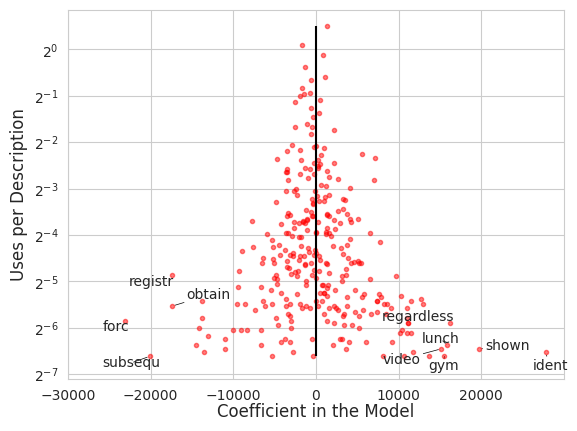

In [ ]:
#### Interpret with a coefficient plot

sns.set_style("whitegrid")
fig, ax = plt.subplots()

# reducing the data points to something more manageable
jd_model = jd_model.sample(n=300)

# plot points
ax.plot(jd_model['score'], jd_model['freq'], color = 'r', alpha = 0.5, linestyle='', marker='o', markersize=3)

# log-transform the Y axis so it's not compressed at the bottom
ax.set_yscale('log', base=2)

# manually set axis ticks depending on data range
# ax.set_yticklabels([.01,.05,.1,.2,.5,1,2,5])

# select top correlations/frequency
top_words = jd_model[(jd_model['score'] > 15000) | (jd_model['freq'] > 1)]

# select bottom correlations/frequency
bottom_words = jd_model[(jd_model['score'] < -15000) & (jd_model['freq'] < 1)]

all_labels = pd.concat([top_words, bottom_words])

x_lab_points = all_labels['score'].tolist()
y_lab_points = all_labels['freq'].tolist()
ngrams = all_labels['ngrams'].tolist()

texts = [ax.text(x_lab_points[i], y_lab_points[i], ngrams[i]) for i in range(len(ngrams))]

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='k', lw=0.5),
            force_static = (0.1,0.5),
            force_text = (0.1,0.5)
            )

ax.vlines(x=0, ymin=min(jd_model['freq']), ymax=max(jd_model['freq']), colors='black')

plt.xlim(-30000, 30000)

xticks = np.arange(-30000, 30000, 10000)
ax.set_xticks(xticks)

plt.xlabel("Coefficient in the Model", fontsize = 12, labelpad=0.05)
plt.ylabel("Uses per Description", fontsize = 12)
plt.show()

# As you can see, the chart is still a bit messy but you can play with the parameters
# to get the labels to fit in
# Better yet, only shoose a few points to annotate

In [ ]:
#### Evaluate Accuracy

test_predict = clf.predict(X_test)
acc = kendall_acc(test_predict, y_test)
print(acc)

     acc  lower  upper
0  57.05  52.29   61.8


In [ ]:
# Create benchmarks

# From our test dataset, extract the index (row numbers) and use this to look up
# the text from the original dataset

ind_test = X_test.index.tolist()
jd_small_test = jd_small.iloc[ind_test]

# creates a list of tokens for each row
jd_small_test['FullDescription'] = [re.sub(r"[^A-Za-z]", " ", i).lower().split() for i in jd_small_test['FullDescription']]
jd_small_test['text_wdct'] = [len(i) for i in jd_small_test['FullDescription']]

# joins all the tokens in the list into one string for sentiment analysis
jd_small_test['FullDescription'] = [' '.join(i) for i in jd_small_test['FullDescription']]

jd_small_test = jd_small_test.reset_index(drop = True)

# sentiment analysis using nltk's tectblob
jd_small_test['text_sentiment'] = [TextBlob(jd_small_test['FullDescription'][i]).sentiment[0] for i in range(len(jd_small_test['FullDescription']))]

acc_wdct = kendall_acc(jd_small_test['salary'], jd_small_test['text_wdct'])
print(acc_wdct)

acc_sentiment = kendall_acc(jd_small_test['salary'], jd_small_test['text_sentiment'])
print(acc_sentiment)


In [ ]:
############ Find examples

# store predictions in data, calculate accuracy
jd_small_test['prediction'] = test_predict
jd_small_test['error'] = abs(jd_small_test['salary'] - jd_small_test['prediction'])
jd_small_test['bias'] = jd_small_test['salary'] - jd_small_test['prediction']

close_high = jd_small_test[(jd_small_test['salary'] > 80000) &
                           (jd_small_test['error'] < 15000)].iloc[:2]
close_high = close_high[['FullDescription', 'salary', 'prediction']]

close_low = jd_small_test[(jd_small_test['salary'] < 25000) &
                           (jd_small_test['error'] < 5000)].iloc[:2]
close_low = close_low[['FullDescription', 'salary', 'prediction']]

print(close_high)
print(close_low)

In [ ]:
# Error analysis - find biggest misses

miss_high = jd_small_test.sort_values('bias').iloc[0:10][['FullDescription', 'salary', 'prediction']]
miss_low = jd_small_test.sort_values('bias').iloc[-10:][['FullDescription', 'salary', 'prediction']]

print(miss_low)

In [ ]:
# A multinomial classifier example
print(jd_small['Category'].value_counts())
# print(jd_small['Category'].nunique())
# select 5 common categories
topcats = jd_small['Category'].value_counts()[1:5].index.tolist()

print(topcats)

In [ ]:
# You will get a warning message regarding SettingWithCopyWarning when assigning values by slicing dataframes
# This is fine and is a standard operation. You can choose to turn off the warning, which will be a
# default standard in Python in the future. For more, see:
# https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

pd.options.mode.chained_assignment = None

In [ ]:


# let's grab some descriptions from different categories
jd_cats = jd_small[(jd_small['ContractTime'] == 'permanent') &
                  (jd_small['ContractType'] == 'full_time') &
                  (jd_small['Category'].isin(topcats)) &
                  (jd_small['Category'].notna())]

jd_cats['desc_wdct'] = [len(re.sub(r"[^A-Za-z]", " ", i).lower().split()) for i in jd_cats['FullDescription']]


jd_cats = jd_cats.rename(columns={"SalaryNormalized": "Salary"})

print(list(jd_cats))
print(jd_cats)

In [ ]:
X = jd_cats['FullDescription']
y = jd_cats['Category']

# 25% or 30% test sizes are fairly standard
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Feature extraction is the same... n-grams
jd_cats_dfm_train = TAB_dfm(X_train, ngrams_range = (0,1))
jd_cats_dfm_test = TAB_dfm(X_test, ngrams_range = (0,1))

# Ensure that we use the same variables in both train and test sets
col_heads_train = set(jd_cats_dfm_train)
col_heads_test = set(jd_cats_dfm_test)

col_heads = col_heads_train.intersection(col_heads_test)

jd_cats_dfm_train = jd_cats_dfm_train[col_heads]
jd_cats_dfm_test = jd_cats_dfm_test[col_heads]

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:528: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:409: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['abov', 'afterward', 'alon', 'alreadi', 'alway', 'ani', 'anoth', 'anyon', 'anyth', 'anywher', 'becam', 'becaus', 'becom', 'befor', 'besid', 'cri', 'describ', 'dure', 'els', 'elsewher', 'empti', 'everi', 'everyon', 'everyth', 'everywher', 'fifti', 'forti', 'henc', 'hereaft', 'herebi', 'howev', 'hundr', 'inde', 'mani', 'meanwhil', 'moreov', 'nobodi', 'noon', 'noth', 'nowher', 'onc', 'onli', 'otherwis', 'ourselv', 'perhap', 'pleas', 'sever', 'sinc', 'sincer', 'sixti', 'someon', 'someth', 'sometim', 'somewher', 'themselv', 'thenc', 'thereaft', 'therebi', 'therefor', 'togeth', 'twelv', 'twenti', 'veri', 'whatev'

In [ ]:
# For multinomial regressions in Python, you can use sklearn or glmnet.
# In this example, we shall use the sklearn package LogisticRegression

from sklearn.linear_model import LogisticRegression

# the rest of the setup is very similar

clf = LogisticRegression()

clf.fit(jd_cats_dfm_train, y_train)
cats_predict_label = clf.predict(jd_cats_dfm_test)

# to output a probability score instead:
print(clf.predict_proba(jd_cats_dfm_test))

# raw accuracy
acc = cats_predict_label == y_test
acc = np.mean(acc * 1)
print(acc)

# Confusion matrix - great for multinomials!
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, cats_predict_label, labels = clf.classes_)
print(cm)

# Annoyingly, sklearn does not provide row or column names for the confusion matrix
# Make sure you add the right names

cm1 = pd.DataFrame(cm, index = clf.classes_, columns = clf.classes_)
print(cm1)



[[6.84783308e-01 3.15216425e-01 2.15218075e-07 5.23207577e-08]
 [4.09055588e-06 9.49211075e-01 5.07316730e-02 5.31615621e-05]
 [1.90600202e-03 8.04274536e-01 1.24777969e-01 6.90414931e-02]
 ...
 [7.97681801e-14 4.59139890e-15 4.72632213e-17 1.00000000e+00]
 [1.60866414e-05 9.99659259e-01 3.24347006e-04 3.07255423e-07]
 [7.96463865e-20 8.85218441e-19 7.85549392e-18 1.00000000e+00]]
0.7902483900643974
[[219  43   6   5]
 [ 42 276  16  15]
 [  5  15 185  32]
 [  7  10  32 179]]
                                  Engineering Jobs  IT Jobs  \
Engineering Jobs                               219       43   
IT Jobs                                         42      276   
PR, Advertising & Marketing Jobs                 5       15   
Teaching Jobs                                    7       10   

                                  PR, Advertising & Marketing Jobs  \
Engineering Jobs                                                 6   
IT Jobs                                                         

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
